<a href="https://colab.research.google.com/github/boba-frog/Fraud-Detection/blob/main/Decision_Trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to your CSV file on Google Drive
file_path = '/content/drive/MyDrive/DATASET/financial_fraud_detection_dataset.csv' # Replace with the actual path

# Load the CSV file into a pandas DataFrame
try:
    df = pd.read_csv(file_path)
    print("DataFrame loaded successfully!")
    print(df.head())
except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
except Exception as e:
    print(f"An error occurred: {e}")

Mounted at /content/drive
DataFrame loaded successfully!
  transaction_id                   timestamp sender_account receiver_account  \
0        T100000  2023-08-22T09:22:43.516168      ACC877572        ACC388389   
1        T100001  2023-08-04T01:58:02.606711      ACC895667        ACC944962   
2        T100002  2023-05-12T11:39:33.742963      ACC733052        ACC377370   
3        T100003  2023-10-10T06:04:43.195112      ACC996865        ACC344098   
4        T100004  2023-09-24T08:09:02.700162      ACC584714        ACC497887   

    amount transaction_type merchant_category location device_used  is_fraud  \
0   343.78       withdrawal         utilities    Tokyo      mobile     False   
1   419.65       withdrawal            online  Toronto         atm     False   
2  2773.86          deposit             other   London         pos     False   
3  1666.22          deposit            online   Sydney         pos     False   
4    24.43         transfer         utilities  Toronto      mo

In [ ]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 6.3 MB/s eta 0:00:00


In [ ]:
!pip install imbalanced-learn

In [ ]:
#ENCODING PT1
# Columns to drop due to high cardinality or irrelevance for direct encoding:
cols_to_drop = ['transaction_id', 'timestamp', 'sender_account', 'receiver_account', 'ip_address']

# Columns for one-hot encoding:
cols_for_onehot = ['transaction_type', 'merchant_category', 'device_used', 'fraud_type', 'payment_channel', 'location', 'device_hash']

# Target variable (no encoding needed for the variable itself):
target_col = 'is_fraud'

print("Plan for encoding categorical variables:")
print(f"Columns to be dropped: {cols_to_drop}")
print(f"Columns for one-hot encoding: {cols_for_onehot}")
print(f"Target variable: {target_col}")

Plan for encoding categorical variables:
Columns to be dropped: ['transaction_id', 'timestamp', 'sender_account', 'receiver_account', 'ip_address']
Columns for one-hot encoding: ['transaction_type', 'merchant_category', 'device_used', 'fraud_type', 'payment_channel', 'location', 'device_hash']
Target variable: is_fraud


In [ ]:
#ENCODING PT2
# Converting USEFUL columns into usable data.
import category_encoders as ce
import pandas as pd

# Drop the columns identified for dropping
cols_to_drop = ['transaction_id', 'timestamp', 'sender_account', 'receiver_account', 'ip_address']

# Columns for one-hot encoding (lower cardinality)
cols_for_onehot = ['transaction_type', 'merchant_category', 'device_used', 'fraud_type', 'payment_channel']

# Columns for target encoding (higher cardinality)
cols_for_target_encoding = ['location', 'device_hash']

# Separate target variable
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

# Apply Target Encoding to high cardinality columns
target_encoder = ce.TargetEncoder(cols=cols_for_target_encoding)
X_target_encoded = target_encoder.fit_transform(X[cols_for_target_encoding], y)

# Drop original high cardinality columns and add target encoded columns
X_processed = X.drop(columns=cols_for_target_encoding)
X_processed = pd.concat([X_processed, X_target_encoded], axis=1)

# Apply one-hot encoding to the lower cardinality columns
X_processed = pd.get_dummies(X_processed, columns=cols_for_onehot, drop_first=True)

# Drop other identified columns
X_processed = X_processed.drop(columns=cols_to_drop)

# Combine processed features with the target variable
df_encoded = pd.concat([X_processed, y], axis=1)


# Display the first few rows of the encoded DataFrame to verify
print("DataFrame after dropping and encoding:")
display(df_encoded.head())

# Display the data types of the encoded DataFrame to verify
print("\nData types of the encoded DataFrame:")
print(df_encoded.dtypes)

DataFrame after dropping and encoding:


,amount,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,location,device_hash,transaction_type_payment,transaction_type_transfer,transaction_type_withdrawal,...,merchant_category_retail,merchant_category_travel,merchant_category_utilities,device_used_mobile,device_used_pos,device_used_web,payment_channel_UPI,payment_channel_card,payment_channel_wire_transfer,is_fraud
0,343.78,NaN,-0.21,3,0.22,0.035815,0.030817,False,False,True,...,False,False,True,True,False,False,False,True,False,False
1,419.65,NaN,-0.14,7,0.96,0.036039,0.030817,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,2773.86,NaN,-1.78,20,0.89,0.036008,0.031238,False,False,False,...,False,False,False,False,True,False,False,True,False,False
3,1666.22,NaN,-0.60,6,0.37,0.035926,0.030817,False,False,False,...,False,False,False,False,True,False,False,False,True,False
4,24.43,NaN,0.79,13,0.27,0.036039,0.030364,False,True,False,...,False,False,True,True,False,False,False,False,False,False



Data types of the encoded DataFrame:
amount                           float64
time_since_last_transaction      float64
spending_deviation_score         float64
velocity_score                     int64
geo_anomaly_score                float64
location                         float64
device_hash                      float64
transaction_type_payment            bool
transaction_type_transfer           bool
transaction_type_withdrawal         bool
merchant_category_grocery           bool
merchant_category_online            bool
merchant_category_other             bool
merchant_category_restaurant        bool
merchant_category_retail            bool
merchant_category_travel            bool
merchant_category_utilities         bool
device_used_mobile                  bool
device_used_pos                     bool
device_used_web                     bool
payment_channel_UPI                 bool
payment_channel_card                bool
payment_channel_wire_transfer       bool
is_fraud           

Running Cross-Validation...
Cross-Validated F1 Scores: [0.89082776 0.83654687 0.82044266 0.8133697  0.81465131]
Mean CV F1 Score: 0.8352

Top 10 Feature Importances:
device_hash: 0.9719
time_since_last_transaction: 0.0273
amount: 0.0003
spending_deviation_score: 0.0002
geo_anomaly_score: 0.0001
velocity_score: 0.0001
location: 0.0001
device_used_pos: 0.0000
payment_channel_card: 0.0000
payment_channel_UPI: 0.0000

Test Set ROC AUC Score: 0.9973

Confusion Matrix:
[[955081   9008]
 [  3700  32211]]

Classification Report:
              precision    recall  f1-score   support

       False       1.00      0.99      0.99    964089
        True       0.78      0.90      0.84     35911

    accuracy                           0.99   1000000
   macro avg       0.89      0.94      0.91   1000000
weighted avg       0.99      0.99      0.99   1000000



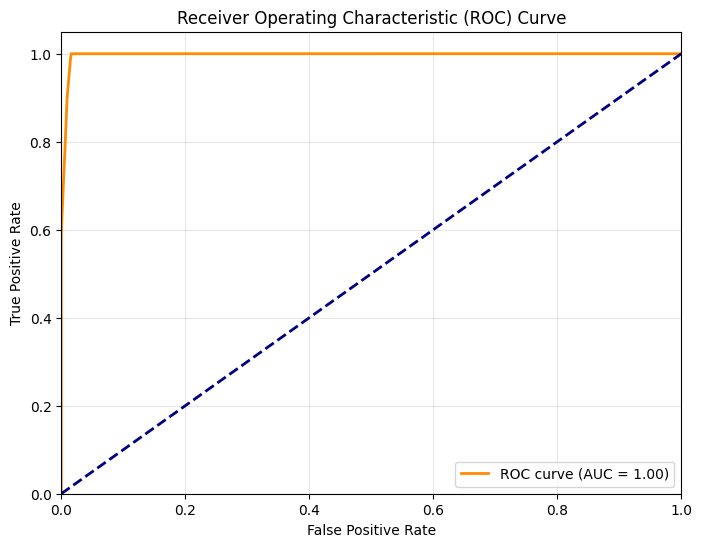

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc, roc_auc_score, classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Separate features (X) and target (y)
X = df_encoded.drop('is_fraud', axis=1)
y = df_encoded['is_fraud']

# 1. Address Overfitting: Limit tree complexity
dt_model = DecisionTreeClassifier(max_depth=10, min_samples_leaf=50, random_state=42)

# 2. Cross-Validation (on a subset if data is too large for quick feedback)
print("Running Cross-Validation...")
cv_scores = cross_val_score(dt_model, X, y, cv=5, scoring='f1')
print(f"Cross-Validated F1 Scores: {cv_scores}")
print(f"Mean CV F1 Score: {cv_scores.mean():.4f}")

# Split for evaluation and importance check
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
dt_model.fit(X_train, y_train)

# 3. Check for Data Leakage via Feature Importance
importances = dt_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

print("\nTop 10 Feature Importances:")
for i in sorted_idx[:10]:
    print(f"{X.columns[i]}: {importances[i]:.4f}")

# Evaluation
y_pred = dt_model.predict(X_test)
y_pred_proba = dt_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nTest Set ROC AUC Score: {roc_auc:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC Curve Visualization
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()